In [1]:
pip install openai==0.28

  Using cached openai-0.28.0-py3-none-any.whl.metadata (13 kB)
Using cached openai-0.28.0-py3-none-any.whl (76 kB)
  Attempting uninstall: openai
    Found existing installation: openai 2.32.0
    Uninstalling openai-2.32.0:
      Successfully uninstalled openai-2.32.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-openai 0.0.6 requires openai<2.0.0,>=1.10.0, but you have openai 0.28.0 which is incompatible.
openai-agents 0.14.2 requires openai<3,>=2.26.0, but you have openai 0.28.0 which is incompatible.


In [2]:
pip  install pandas matplotlib prophet

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ==============================
# 1. Setup & Imports
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import openai

Importing plotly failed. Interactive plots will not work.


In [4]:
# ==============================
# 2. Utility Functions
# ==============================

def load_data(filepath: str) -> pd.DataFrame:
    """Load and preprocess sales data."""
    df = pd.read_csv(filepath)
    df.rename(columns={"date":"ds","sales":"y"}, inplace=True)
    df['ds'] = pd.to_datetime(df['ds'])
    return df

def forecast_sales(df: pd.DataFrame, periods: int = 30) -> pd.DataFrame:
    """Generate baseline forecast using Prophet."""
    model = Prophet()
    model.fit(df)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)
    return forecast, model

def adjust_with_llm(forecast: pd.DataFrame, context: str) -> str:
    """Use OpenAI LLM to adjust forecast with contextual signals."""
    prompt = f"""
    Forecast shows {forecast['yhat'].tail(1).values[0]} units.
    Adjust considering {context}.
    Provide reasoning and adjusted forecast.
    """
    response = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[{"role":"user","content":prompt}]
    )
    return response["choices"][0]["message"]["content"]

def calculate_inventory_metrics(df: pd.DataFrame, lead_time: int = 7, service_level_factor: float = 1.65):
    """Calculate safety stock and reorder point."""
    demand_rate = df['y'].mean()
    std_dev = df['y'].std()
    safety_stock = service_level_factor * std_dev * np.sqrt(lead_time)
    reorder_point = demand_rate * lead_time + safety_stock
    return safety_stock, reorder_point

def plot_dashboard(df: pd.DataFrame, forecast: pd.DataFrame, reorder_point: float):
    """Visualize sales history, forecast, and reorder point."""
    plt.figure(figsize=(10,6))
    plt.plot(df['ds'], df['y'], label="Historical Sales")
    plt.plot(forecast['ds'], forecast['yhat'], label="Baseline Forecast")
    plt.axhline(reorder_point, color='red', linestyle='--', label="Reorder Point")
    plt.legend()
    plt.title("Inventory Forecast Dashboard")
    plt.show()

16:37:31 - cmdstanpy - INFO - Chain [1] start processing
16:37:32 - cmdstanpy - INFO - Chain [1] done processing


LLM Adjusted Forecast: The Diwali festival in India often creates a significant increase in demand for many goods and services due to its cultural and religious significance. People indulge in large scale shopping and gifting, translating into increased sales for businesses. 

If we assume that during the Diwali season demand spikes by around 25% (this can be determined by analyzing historical sales data), we can adjust our forecast accordingly.

Adjusted forecast = 128.51036435521456 units + 25% of 128.51036435521456 units

Adjusted forecast = 128.51036435521456 units + 32.12759108880364 units

Adjusted forecast = 160.6379554440182 units

It is worth mentioning that this is a hypothetical percentage increase. The actual figures can vary widely depending on the type of product, geographical location, target audience, etc. Therefore, past sales data and other market research should be used to more accurately predict the potential increase in demand during Diwali.
Safety Stock: 61.218704

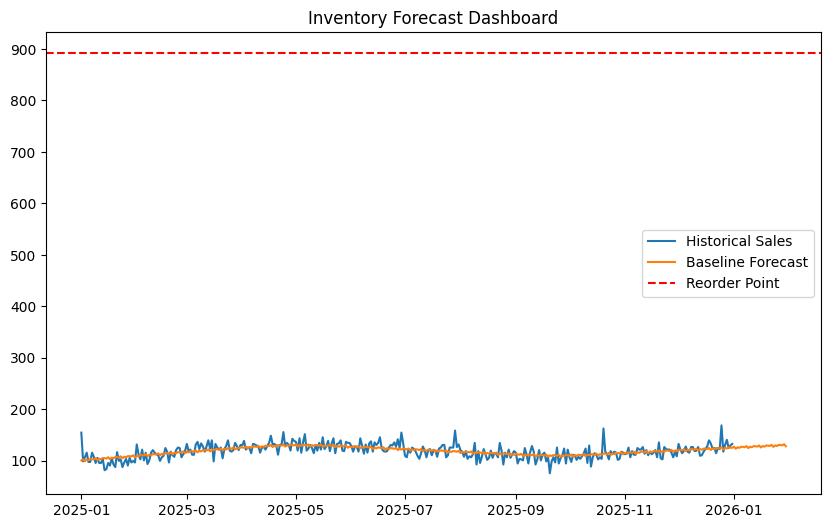

In [5]:
# ==============================
# 3. Workflow Execution
# ==============================
# Load data
df = load_data("sales_history.csv")

# Forecast
forecast, model = forecast_sales(df, periods=30)

# LLM Adjustment
adjusted = adjust_with_llm(forecast, context="seasonal demand spikes during Diwali")
print("LLM Adjusted Forecast:", adjusted)

# Inventory Metrics
safety_stock, reorder_point = calculate_inventory_metrics(df)
print("Safety Stock:", safety_stock)
print("Reorder Point:", reorder_point)

# Visualization
plot_dashboard(df, forecast, reorder_point)
